## Clinical Data Analysis: Index validation and Regression

<div style="padding: 15px; border: 1px solid #003152; border-radius: 5px; background-color: #fff5ef; color: #003152;">

**Project:** Quantifying Clinical Gaps in Valvular Heart Disease: Using the Medication Burden Index (MBI) to Triage High-Complexity Intervention Candidates.  
**Source:** Clinical Analytics Mart derived from 3NF Relational Schema.    
**Key analysis:** Receiver Operating Characteristic (ROC/AUC) Curve Analysis and Ordinary Least Squares (OLS) regressions and residual analysis.  
**Version:** 1.1 (Post-Audit)  

---
**Technical Focus:** This notebook transitions from structured data warehousing into analytical clinical decision support. By executing comparative pre/post-intervention cohort analysis and optimizing predictive cutoffs, we isolate specific patient populations crossing critical clinical thresholds.  
**Key Goal:** Quantify the discriminative power and precision thresholds of MBI-driven triage, validating the medication index as a high-precision, low-overhead proxy for anatomical complexity and critical hemodynamic collapse.

</div>

In [39]:
# 1. IMPORTS
# ==========================================

# %matplotlib inline
import pandas as pd
import numpy as np
from IPython.display import display, Markdown, HTML
import re
import missingno as msno
import matplotlib.colors as mcolors
import statsmodels.api as sm
# from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import roc_curve, auc, f1_score, precision_score, recall_score, confusion_matrix
from scipy.stats import kruskal, chi2_contingency
import scipy.stats as sstats
# import scikit_posthocs as sp
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import mysql.connector
from mysql.connector import Error
import sys
import os
from pathlib import Path
from dotenv import load_dotenv

sys.path.append(str(Path.cwd().parent))
from modules.config import ClinicalConfig # The 'Medical Brain' source

load_dotenv()

True

In [40]:
# 2. STATISTICS CLASS
# ==========================================

class Statistics:
    def __init__(self, dataframe, config):
        self.df = dataframe
        self.config = config
    
    def roc(self, predictor_col='mbi', target=None, label=None):
        """
        Generalized ROC analysis.
        Tests how well a chosen column (predictor_col) predicts Clinical Complexity.
        """
        # Ensure the column exists to avoid a KeyError
        if predictor_col not in self.df.columns:
            print(f"Error: {predictor_col} not found in dataframe.")
            return

        # Dynamic Target Resolution
        if target is None:
            # Default logic: Capturing 'Rising Risk' (Score 1 or higher)
            y_true = (self.df['complexity_score'] > 0).astype(int)
            target_label = "Clinical Complexity"
        elif isinstance(target, str):
            # If a column name is passed
            y_true = self.df[target].astype(int)
            target_label = label if label is not None else target
        else:
            # If a boolean mask/expression is passed (e.g. self.df['Sev_PH'] >= 3.0)
            y_true = target.astype(int)
            target_label = label if label is not None else "Custom Clinical Threshold"

        # Recalculates ROC Metrics
        # Drop NAs for the specific predictor to prevent the roc_curve function from failing
        # temp_df = self.df[['Is_Complex_Case', predictor_col]].dropna()
        y_scores = self.df[predictor_col]

        fpr, tpr, thresholds = roc_curve(y_true, y_scores)
        roc_auc = auc(fpr, tpr)

        # Finding the Optimal Cutoff using Youden's J statistic
        j_scores = tpr - fpr
        best_idx = np.argmax(j_scores)
        best_cutoff = thresholds[best_idx]

        # Visualization
        print(f"ROC visualization for {predictor_col}\n" + '-'*40)
        plt.figure(figsize=(10, 7))
        plt.plot(fpr, tpr, color='#08519c', lw=3, label=f'ROC curve (AUC = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='#bdbdbd', linestyle='--', label='Random Classifier')
        
        # Dynamic Label for the Scatter Point
        plt.scatter(fpr[best_idx], tpr[best_idx], color='black', s=100, zorder=5,
                    label=f'Optimal {predictor_col} Cutoff: {best_cutoff:.2f}')

        plt.xlabel('False Positive Rate (1 - Specificity)')
        plt.ylabel('True Positive Rate (Sensitivity)')
        
        # Dynamic Title
        plt.title(f'Predicting: {target_label} via {predictor_col}', fontsize=14)
        plt.legend(loc='lower right')
        plt.grid(alpha=0.3)
        plt.show()

        print(f"Analysis Complete: A value of {predictor_col} above {best_cutoff:.2f} is the best predictor for this variable.\n")
    
    def validate_predictor(self, threshold):
        """
        Calculate the F1-Score to validate if MBI > 4.0 
        is a reliable proxy for Anatomical Complexity >= 2.0.
        """
        y_true = self.df['is_complex_anatomic']
        y_pred = self.df['MBI_Predicted_High']
        
        f1 = f1_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred)
        recall = recall_score(y_true, y_pred)
        
        # Portfolio-ready output
        print(f"MBI Threshold Validation (> {threshold})\n" + '-'*40)
        print(f"F1-Score:  {f1:.3f}")
        print(f"Precision: {precision:.3f} (Reliability: When MBI is high, is the patient actually sick?)")
        print(f"Recall:    {recall:.3f} (Sensitivity: Does MBI catch all the sick patients?)")
        cm = confusion_matrix(y_true, y_pred)
        
        return cm 

    def _prepare_regression_features(self, df_to_fix):
        # Perform operations on the passed dataframe and return it
        df_to_fix['Gender_Male'] = (df_to_fix['gender'].str.lower() == 'male').astype(int)
        df_to_fix['Mitral_Mixed_Score'] = df_to_fix['sev_ms'] * df_to_fix['sev_mr']
        df_to_fix['Aortic_Mixed_Score'] = df_to_fix['sev_as'] * df_to_fix['sev_ar']
        return df_to_fix

    def run_regression(self, y_var, strata=None, excluded_features=None):
        """
        Modular engine to execute stratified regressions.
        :param y_var: The dependent variable (e.g., 'MBI' or 'RVSP_Imputed')
        :param feature_list: List of predictors to include
        :param strata: Specific 'Approach' to run (e.g., 'Native'). If None, loops all.
        """
        working_df = self.df.copy()

        # 1. Prepare features ONLY on the working copy
        working_df = self._prepare_regression_features(working_df)

        # 2. Ternary switch for strata list
        target_approaches = [strata] if strata else ['Native', 'Percutaneous', 'Surgical']

        # 3. Determine if we are doing a deep dive (single strata selected)
        is_deep_dive = len(target_approaches) == 1   
        
        # 4. Expand the feature list
        demographics = self.config.regression_demographics
        lesions = self.config.regression_lesions
        echo = self.config.regression_echo
        
        features = demographics + lesions + echo
        
        # 5. SILENCING LOGIC: Remove variables the user wants to ignore
        if excluded_features:
            features = [f for f in features if f not in excluded_features]

        # 6. Stratification Logic
        status_results = []
        all_subs = []
        for status in target_approaches:
            # Slice a deep copy for the specific cohort
            sub_df = working_df[working_df['approach'] == status].copy()
            current_features = [f for f in features if f in self.df.columns and f != y_var]
            
            # Check if we have any features left to run!
            if not current_features:
                print(f"[!] No valid features found for {status}. Skipping.")
                continue

            # Isolate the group
            sub_df = sub_df.dropna(subset=current_features + [y_var])
            
            if len(sub_df) < 15: # Minimum threshold to avoid running on low statistical power
                print(f"\n[!] Stratum '{status}' skipped: Insufficient data (n={len(sub_df)})")
                continue
            
            # Fit Model
            X = sm.add_constant(sub_df[current_features])
            y = sub_df[y_var]
            model = sm.OLS(y, X).fit()
            
            # Attach residuals only to the temporary slice
            sub_df[f'{y_var}_Residual'] = model.resid

            # Store full results for the report
            status_results.append({'status': status, 'model': model, 'n': len(sub_df)})
            all_subs.append(sub_df)

        # 7. Pass the 'status_results' list instead of a single 'status' string
        # Move outside the loop so the Overview can consolidate all results
        if status_results:
            self._print_clinical_report(status_results, y_var, is_deep_dive)

        return pd.concat(all_subs) if all_subs else pd.DataFrame()

    def _print_clinical_report(self, status_results, y_var, is_deep_dive):
        """
        Internal helper to toggle between a clean table and a full summary.
        """
        if is_deep_dive:
            res = status_results[0]
            print(f"\n{'='*40}\nDEEP DIVE: {y_var} {res['status'].upper()} (n={res['n']})\n{'='*40}")
            print(res['model'].summary())
        else:
            # 2. OVERVIEW: Build a Master Comparison Table
            print(f"\n{'='*40}\nCROSS-STRATA COMPARISON: {y_var}\n{'='*40}")

            all_cols = []
            for item in status_results:
                # Extract Params and P-Values
                df_res = pd.concat([item['model'].params, item['model'].pvalues], axis=1)
                df_res.columns = [f"{item['status']} Coef", f"{item['status']} P"]
                
                # Add Significance Stars to the Coef column for readability
                df_res[f"{item['status']} Coef"] = df_res.apply(
                    lambda row: f"{row.iloc[0]:.3f} " + 
                    ('**' if row.iloc[1] < 0.01 else ('*' if row.iloc[1] < 0.05 else '')),
                    axis=1
                )
                all_cols.append(df_res[[f"{item['status']} Coef"]]) # Keep only the starred Coef for the table

            # Join all strata columns together
            master_table = pd.concat(all_cols, axis=1).fillna('-')
            
            # Display as a pretty HTML table
            display(HTML(f"<h3>Cohort Coefficient Comparison: {y_var}</h3>"))
            display(master_table)
            print("Notes:   ** - p < 0.01 | * - p<0.05\n")

    def get_global_p(self, var, strata='MBI_Zone', data=None):
        """
        Compute the Kruskal-Wallis H-test across groups.
        Used to determine if there is a statistically significant difference 
        in a parameter (e.g., MBI) across different zones or intervention groups.
        """
        # Use the provided data or fall back to the class dataframe
        df_to_use = data if data is not None else self.df
        
        # Ensure we don't have NaNs in the grouping or the variable
        clean_df = df_to_use.dropna(subset=[var, strata])
        
        if clean_df.empty:
            return "N/A"

        if pd.api.types.is_numeric_dtype(clean_df[var]):
            # Continuous data: Kruskal-Wallis
            groups = [group[var].values for name, group in clean_df.groupby(strata)]
            if len(groups) < 2: return "N/A"
            _, p = kruskal(*groups)
        else:
            # Categorical data: Chi-Square
            contingency_table = pd.crosstab(clean_df[strata], clean_df[var])
            _, p, _, _ = chi2_contingency(contingency_table)
            
        # Clinical formatting (Journal standard)
        return f"{p:.3f}" if p >= 0.001 else "<0.001"
    
    def format_stat(self, df_subset, col, mode='mean'):
        if df_subset.empty:
            return "0" if mode == 'count' else "-"
        
        if mode == 'pct':
            val = (df_subset[col] == 'Female').mean() * 100
            return f"{val:.1f}%"
        
        if mode == 'count':
            # Sums boolean or 1/0 columns to get raw count
            cnt = int(df_subset[col].sum())
            return f"{cnt}"
            
        mean = df_subset[col].mean()
        std = df_subset[col].std()
        return f"{mean:.1f} ± {std:.1f}"

In [ ]:
# 3. VISUALIZER CLASS
# ==========================================

class Visualizer:
    def __init__(self, dataframe, config):
        self.df = dataframe
        self.config = config
        plt.style.use('seaborn-v0_8-white') 
        sns.set_context("paper", font_scale=1.2)
        plt.rcParams['font.family'] = 'sans-serif'

    def validate_vis(self, matrix, x_label, y_label, title):
        # Generate confusion matrix
        plt.figure(figsize=(8,6))
        sns.heatmap(matrix, annot=True, fmt='d', cmap='GnBu', 
                    xticklabels=['MBI Low', 'MBI High'], 
                    yticklabels=['Healthy', 'Cases'])
        plt.xlabel(x_label)
        plt.ylabel(y_label)
        plt.title(title)
        print("\nConfusion matrix visualization\n" + '-'*40)
        plt.show()

    def residual_distribution(self, results_df, y_var='MBI'):
        """
        Plots the error (Actual - Predicted) to identify where the model struggles.
        """
        res_col = f'{y_var}_Residual'
        
        if res_col not in results_df.columns:
            print(f"[!] Error: Column {res_col} not found in the provided DataFrame.")
            return

        # Faceted Histogram for Scientific Transparency
        g = sns.FacetGrid(results_df, col="approach", hue="approach", 
                          palette="Blues", height=4, aspect=1.2)
        
        g.map(sns.histplot, res_col, kde=True, element="step", alpha=0.5)
        
        # Format for a clinical report
        g.set_axis_labels(f"Residuals (Actual - Predicted {y_var})", "Patient Count")
        g.set_titles("Strata: {col_name}")
        
        for ax in g.axes.flatten():
            ax.axvline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
            # Annotate regions
            ax.text(ax.get_xlim()[0]*0.9, ax.get_ylim()[1]*0.8, "Under-predicting", 
                    color='darkblue', fontsize=9, weight='bold')
            ax.text(ax.get_xlim()[1]*0.1, ax.get_ylim()[1]*0.8, "Over-predicting", 
                    color='darkred', fontsize=9, weight='bold')

        plt.subplots_adjust(top=0.85)
        g.fig.suptitle(f'Model Error Distribution: {y_var} Prediction Accuracy', fontsize=16)
        plt.show()

    def diagnostic_plots(self, results_df, y_var='MBI'):
        """
        Histogram + Q-Q Plot.
        Proves that the model's errors follow a normal distribution,
        validating the use of p-values and linear assumptions.
        """
        res_col = f'{y_var}_Residual'
        if res_col not in results_df.columns:
            print(f"[!] Error: {res_col} not found.")
            return

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        # 1. Histogram with KDE
        sns.histplot(results_df[res_col], kde=True, ax=ax1, color='#08519c', bins=20)
        ax1.set_title(f'Residual Distribution: {y_var}', fontsize=14)
        ax1.set_xlabel('Error (Actual - Predicted)')
        
        # 2. Q-Q Plot (Normal Probability Plot)
        sstats.probplot(results_df[res_col], dist="norm", plot=ax2)
        ax2.get_lines()[0].set_markerfacecolor('#08519c')
        ax2.get_lines()[0].set_alpha(0.5)
        ax2.set_title('Normal Q-Q Plot', fontsize=14)
        
        plt.tight_layout()
        plt.show()
    
    def plot_discordance_scatter(self):
        """
        Generates MBI vs RVSP discordance scatter plot on native valve status.
        Calculates OLS residuals internally and returns the classified native dataframe.
        """
        import statsmodels.api as sm
        
        # Select Native Data from internal df copy
        native_df = self.df[self.df['approach'].str.lower() == 'native'].copy()

        # 1. Statistical Core: Residual Calculation
        X = sm.add_constant(native_df['rvsp_imputed'])
        model = sm.OLS(native_df['mbi'], X).fit()
        native_df['MBI_Residual'] = native_df['mbi'] - model.predict(X)

        # Define Discordance Categories
        def classify_discordance(res):
            if res > 2.0: return 'High MBI (Aggresive treatment)'
            if res < -2.0: return 'Low MBI (Under-medicated)'
            return 'Concordant'

        native_df['Status'] = native_df['MBI_Residual'].apply(classify_discordance)

        # Visualization: Clean Regression with Marginal Distributions
        plt.figure(figsize=(11, 7))
        sns.set_style("ticks")

        # Plot the regression line with a 95% Confidence Interval
        sns.regplot(x='rvsp_imputed', y='mbi', data=native_df, 
                    scatter=False, color='#2c3e50', line_kws={"linewidth": 1.5, "alpha": 0.8})

        # Scatterplot with uniform point size
        ax = sns.scatterplot(x='rvsp_imputed', y='mbi', hue='Status', 
                             palette={'Concordant': '#bdc3c7', 
                                      'High MBI (Aggresive treatment)': '#2980b9', 
                                      'Low MBI (Under-medicated)': '#e74c3c'},
                             data=native_df, s=80, alpha=0.9, edgecolor='white', linewidth=0.5)

        # Clinical Benchmarks (Thresholds)
        plt.axhline(y=5.5, color='black', linestyle='--', linewidth=1, alpha=0.3)
        plt.axvline(x=60, color='black', linestyle='--', linewidth=1, alpha=0.3)

        # Annotating the "Safety Gap"
        plt.fill_between([60, 155], 0, 5.5, color='#e74c3c', alpha=0.05) 
        plt.text(62, 0.2, 'CRITICAL ZONE\n(Under-medicated / High RVSP)', color='#c0392b', fontsize=9, fontweight='bold')
        plt.fill_between([0, 60], 5.5, 10.5, color='#2980b9', alpha=0.05) 
        plt.text(2, 8, 'COMPLEXITY ZONE\n(Aggresive management)', color='#2980b9', fontsize=9, fontweight='bold')

        # Styling
        plt.title('MBI vs. RVSP Discordance: Identifying Triage Gaps', fontsize=15, loc='left', pad=15)
        plt.xlabel('RVSP (mmHg) — [Reference Standard]', fontsize=11)
        plt.ylabel('Medication Burden Index (MBI) — [Index Test]', fontsize=11)
        plt.legend(title='Clinical Status', frameon=False, bbox_to_anchor=(1, 1))

        sns.despine()
        plt.tight_layout()
        plt.show()
        
        return native_df
    
    def plot_discordance_bars(self, native_df):
        """
        Generates grouped horizontal bar chart exposing clinical drivers of discordance.
        """
        under_medicated = native_df[native_df['Status'] == 'Low MBI (Under-medicated)']
        complex_masked = native_df[native_df['Status'] == 'High MBI (Aggresive treatment)']

        # Clinical drivers of discordance based on their MBI/RVSP relationship
        pathology_markers = ['mixed_mitral', 'mixed_aortic', 'multi_valve', 'afib_present', 'ph_significant']

        # Prepare data for the frequency plot
        under_med = under_medicated[pathology_markers].sum()
        complex_high = complex_masked[pathology_markers].sum()

        # Create clean DataFrame for plotting
        freq_df = pd.DataFrame({
            'Under-medicated': under_med,
            'Aggresive treatment': complex_high
        }).reset_index().rename(columns={'index': 'Pathology'})

        # Visualization: Grouped Horizontal Bar Chart
        plt.figure(figsize=(10, 6))
        sns.set_style("white")

        # Melt the dataframe for Seaborn
        melted_freq = freq_df.melt(id_vars='Pathology', var_name='Group', value_name='Count')

        ax = sns.barplot(data=melted_freq, y='Pathology', x='Count', hue='Group', 
                         palette={'Under-medicated': '#e74c3c', 
                                  'Aggresive treatment': '#2980b9'})

        # Add count labels to bars for transparency
        for container in ax.containers:
            ax.bar_label(container, padding=3, fontsize=10, fontweight='bold')

        plt.title('Clinical Drivers of Discordance (Frequency Counts)', fontsize=14, loc='left', pad=15)
        plt.xlabel('Number of Patients (N)', fontsize=11)
        plt.ylabel('')
        plt.legend(frameon=False)
        sns.despine()
        plt.tight_layout()
        
        print('Clinical Drivers of Discordance (Frequency Counts)\n' + '-'*40)
        print(f'Under-medicated (n={len(under_medicated)})')
        print(f'Aggresive treatment (n={len(complex_masked)})')
        plt.show()

    def plot_triage_map(self):
        """
        Generates dual-axis MBI triage map with secondary strategic impact parabolic curve.
        """
        sns.set_theme(style="white")
        fig, ax1 = plt.subplots(figsize=(12, 7))

        # PRIMARY AXIS: RVSP vs MBI Scatter (Aligned to lowercase schema)
        sns.scatterplot(data=self.df, x='mbi', y='rvsp_imputed', alpha=0.6, color='#2c3e50', s=60, ax=ax1, label='Patient Cohort')

        # Define Triage Zones
        ax1.axvspan(0, 4.0, color='#3e8cc0', alpha=0.1, label='Zone 1: Standard care (MBI < 4.0)')
        ax1.axvspan(4.0, 5.5, color='#f1c40f', alpha=0.15, label='Zone 2: Optimal window (4.0-5.5)')
        ax1.axvspan(5.5, 8.0, color='#e74c3c', alpha=0.1, label='Zone 3: High risk (> 5.5)')

        # Clinical Threshold Markers
        ax1.axvline(2.27, color='#3e8cc0', linestyle='--', linewidth=1.5)
        ax1.text(2.33, 105, 'Native Constant\n(2.27)', color='#385b7b', fontweight='bold')

        ax1.axvline(4.0, color='#d35400', linestyle='--', linewidth=1.5)
        ax1.text(4.1, 105, 'Complexity Floor\n(4.0)', color='#d35400', fontweight='bold')

        ax1.axvline(5.25, color='#c0392b', linestyle=':', linewidth=2)
        ax1.text(5.35, 95, 'Critical Threshold\n(RVSP > 60)', color='#c0392b', fontweight='bold')

        # SECONDARY AXIS: The "U-Shape" Benefit Curve
        ax2 = ax1.twinx()
        x_curve = np.linspace(0, 8, 100)
        benefit_curve = -0.5 * (x_curve - 4.75)**2 + 10 
        benefit_curve = np.clip(benefit_curve, 0, 10)

        ax2.plot(x_curve, benefit_curve, color='#2980b9', linewidth=3, label='Intervention Benefit')
        ax2.fill_between(x_curve, 0, benefit_curve, color='#2980b9', alpha=0.1)

        # Styling & Labels
        ax1.set_xlabel('Medication Burden Index (MBI)', fontsize=12, fontweight='bold')
        ax1.set_ylabel('RVSP (mmHg)', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Intervention Impact / Priority', fontsize=12, fontweight='bold', color='#2980b9')
        plt.title('MBI-Driven Triage: Mapping Hemodynamic Severity to Intervention Impact', fontsize=15, pad=20, fontweight='bold')

        # Legend and limits
        lines_1, labels_1 = ax1.get_legend_handles_labels()
        lines_2, labels_2 = ax2.get_legend_handles_labels()
        ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', frameon=True)
        ax1.set_xlim(0, 8)
        ax1.set_ylim(10, 120)
        ax2.set_ylim(0, 15)
        ax2.set_yticks([]) 

        plt.tight_layout()
        plt.show()

In [42]:
# 4. TABLES CLASS
# ==========================================

class Tables:
    def __init__(self, dataframe, stats_engine):
        self.df = dataframe.copy()
        self.stats = stats_engine

    def _slicer(self, df_target, bins=None, labels=None):

        # Default fallback to project standard cutoffs if not provided
        if bins == None: bins = [0.0, 4.0, 5.5, np.inf]
        if labels == None: labels = ['Zone 1', 'Zone 2', 'Zone 3']

        working_df = df_target.copy()
        
        # Apply clinical cutoffs safely using the 2.0 matrix lowercase 'mbi' column
        working_df['MBI_Zone'] = pd.cut(working_df['mbi'], bins=bins, labels=labels, right=False)
        
        # Calculate precise group counts for metadata display
        counts = working_df['MBI_Zone'].value_counts()
        header_labels = {zone: f"{zone} (n={counts.get(zone, 0)})" for zone in labels}
        
        return working_df, header_labels

    def table_one(self, bins=None, labels=None):
        """
        Constructs Table 1: Baseline Characteristics Stratified by MBI Triage Zone.
        """
        if labels is None: labels = ['Zone 1', 'Zone 2', 'Zone 3']
        
        # Slice the cohort and get the header dictionary
        sliced_df, header_labels = self._slicer(self.df, bins, labels)
        
        rows = [
            ('Age (years)', 'age', 'mean'),
            ('Female (%)', 'gender', 'pct'),
            ('Heart Rate (bpm)', 'heart_rate', 'mean'),
            ('Systolic BP (mmHg)', 'sbp_r', 'mean'),
            ('Diastolic BP (mmHg)', 'dbp_r', 'mean'),
            ('RVSP (mmHg)', 'rvsp_imputed', 'mean'),
            ('LVEF (%)', 'lvef_score', 'mean'),
            ('MBI', 'mbi', 'mean')
        ]
        
        table_one = pd.DataFrame()
        
        # Column A: All Patients (N=152)
        col_all = []
        for label, col, is_pct in rows:
            col_all.append(self.stats.format_stat(sliced_df, col, is_pct))
        table_one['All Patients (N=152)'] = col_all
        
        # Columns B-D: Triage Zones
        for zone in labels:
            zone_df = sliced_df[sliced_df['MBI_Zone'] == zone]
            col_zone = []
            for label, col, is_pct in rows:
                col_zone.append(self.stats.format_stat(zone_df, col, is_pct))
            table_one[header_labels[zone]] = col_zone
            
        table_one.index = [r[0] for r in rows]
        return table_one

    def table_two(self):
        """
        Constructs Table 2: Baseline Characteristics Stratified by Valve Status.
        """
        rows = [
            ('Age (years)', 'age', 'mean'),
            ('Female (%)', 'gender', 'pct'),
            ('Heart Rate (bpm)', 'heart_rate', 'mean'),
            ('Systolic BP (mmHg)', 'sbp_r', 'mean'),
            ('Diastolic BP (mmHg)', 'dbp_r', 'mean'),
            ('RVSP (mmHg)', 'rvsp_imputed', 'mean'),
            ('LVEF (%)', 'lvef_score', 'mean'),
            ('MBI', 'mbi', 'mean')
        ]
        
        table_two = pd.DataFrame()
        
        # Column A: All Patients (N=152)
        col_all = []
        for label, col, is_pct in rows:
            col_all.append(self.stats.format_stat(self.df, col, is_pct))
        table_two['All Patients (N=152)'] = col_all
        
        # Columns B-D: Valve Status Strata
        for approach in ['Native', 'Percutaneous', 'Surgical']:
            app_df = self.df[self.df['approach'].str.lower() == approach.lower()]
            table_two[f'{approach} (n={len(app_df)})'] = [
                self.stats.format_stat(app_df, col, is_pct) for label, col, is_pct in rows
            ]
            
        table_two.index = [r[0] for r in rows]
        return table_two

In [43]:
# 5. DATA LOADING
# ==========================================
config = ClinicalConfig()

# Load
output = r'..\data\processed\df_output.csv'
if not os.path.exists(output):
    print(f"CRITICAL ERROR: File not found at {os.path.abspath(output)}")
else:
    load = pd.read_csv(output, dtype={'ID': str})
    print(f"Successfully loaded {len(load)} patient records.")

df = load.copy()

Successfully loaded 152 patient records.


In [44]:
stats = Statistics(df, config)
viz = Visualizer(df, config)
tabs = Tables(df, stats)

### 📈 ROC Analysis: Finding the Triage "Cutoff"
---

To provide actionable value for the brigade, we determine the predictive power of the MBI in identifying "High Complexity" surgical candidates.

* **The Metric:** We generate a Receiver Operating Characteristic (ROC) curve and calculate the Area Under the Curve (AUC).

* **The Optimal Cutoff:** We identify the MBI score at a cutoff of $4.0$ provides the best balance of sensitivity (catching all sick patients) and specificity (not over-flagging healthy ones).

ROC visualization for mbi
----------------------------------------


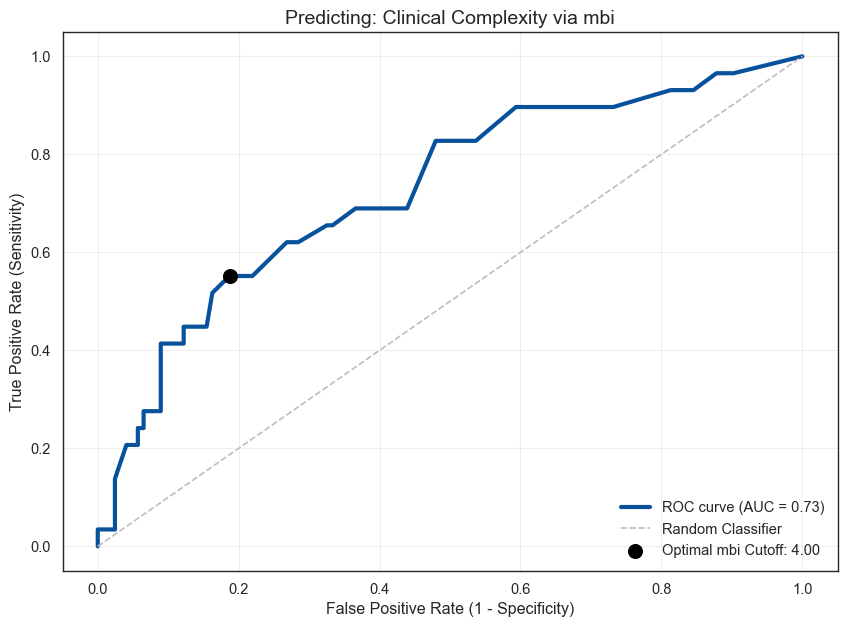

Analysis Complete: A value of mbi above 4.00 is the best predictor for this variable.

MBI Threshold Validation (> 4.0)
----------------------------------------
F1-Score:  0.421
Precision: 0.800 (Reliability: When MBI is high, is the patient actually sick?)
Recall:    0.286 (Sensitivity: Does MBI catch all the sick patients?)

Confusion matrix visualization
----------------------------------------


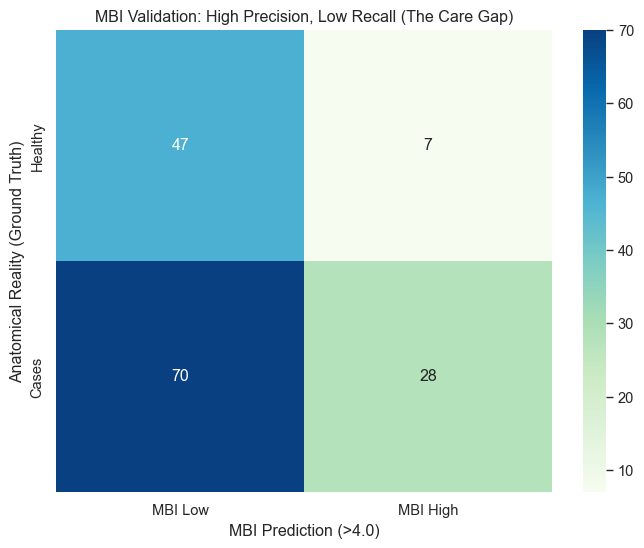

In [45]:
# ROC analysis
stats.roc(predictor_col='mbi')

# Validation of the MBI threshold
lowercase_lesions = [col.lower() for col in config.lesions_anatomic]

# 2.0 for a moderate cutoff
anatomical_threshold = 2.0 
df['is_complex_anatomic'] = (df[lowercase_lesions].max(axis=1) >= anatomical_threshold).astype(int)

# Apply the MBI Cutoff (The Predictor)
mbi_cutoff = 4.0
df['MBI_Predicted_High'] = (df['mbi'] > mbi_cutoff).astype(int)
matrix = stats.validate_predictor(mbi_cutoff)
viz.validate_vis(matrix, 
                 'MBI Prediction (>4.0)', 'Anatomical Reality (Ground Truth)', 
                 'MBI Validation: High Precision, Low Recall (The Care Gap)'
)

<div style="padding: 15px; border: 1px solid #003152; border-radius: 5px; background-color: #eff9ff; color: #003152;">
    <strong style="font-size: 1.2em;">Model Validation: Quantifying the MBI as a Triage Filter</strong> 
    <p>The combination of the ROC Curve and the Confusion Matrix reveals how the Medication Burden Index (MBI) serves as a "High-Specificity" filter for clinical triage.</p>
    <p><strong>Predictive Power (ROC Analysis):</strong> The ROC curve shows an <strong>AUC of 0.73.</strong> In a field setting with messy, free-text data, an AUC above 0.70 is a significant parameter. It proves that a patient's medication list alone carries a strong enough signal to distinguish anatomical complexity from health, far better than a random guess.</p>
    <p><strong>High Precision (Reliability Factor):</strong> The confusion matrix yields a Precision of 0.80, meaning that when the MBI flags a patient as "High Risk" (> 4.0), the model is correct <strong>80% of the time.</strong> In a high-volume clinical setting, this high Positive Predictive Value (PPV) ensures that an "MBI High" alert serves as a reliable trigger, almost certainly warranting a thorough review and confirmatory transesophageal ecocardiographic evaluation.</p>
    <p><strong>Low Recall (The Care Gap):</strong> The model shows a lower Recall of 0.286 (identifying 28 out of 98 complex cases). While this might look like a technical weakness, it actually reveals a profound clinical insight:
        <ul>
            <li><strong>The "Untreated" Population:</strong> These 70 patients (False Negatives) have complex anatomical disease but a Low MBI. This suggests they are "under-managed"—sick patients who are not yet on the aggressive medication regimens their condition requires.</li>
            <li><strong>The Opportunity:</strong> The MBI doesn't just find sick patients; it identifies the <strong>Care Gap</strong>. These are the patients who have the disease but haven't been optimized medically.</li>
        </ul>
    </p>
</div>

### 🧮 Regression Analysis: What Drives the Medication Burden?
---

We run `run_regression()` to determine if our engineered Medication Burden Index (MBI) truly reflects the anatomical severity recorded during Phase 1.

**The Model:**

$$MBI = \beta_0 + \beta_1(RVSP) + \beta_2(MS~MG) + \beta_3(AO~V2~max) + \epsilon$$

* **Key Findings:** We look for statistically significant coefficients ($\rho < 0.05$) for markers like RVSP (Right Ventricular Systolic Pressure).

* **Interpretation:** A strong positive correlation proves that as a patient's heart physically struggles (higher pressures, larger chambers), their pharmacological "burden" increases proportionally.


CROSS-STRATA COMPARISON: mbi


,Native Coef,Percutaneous Coef,Surgical Coef
const,2.293 **,1.833,0.436
sev_ms,0.181,0.741,0.730 *
sev_mr,0.563 *,-0.167,0.521
sev_as,0.082,0.000,0.501 *
sev_ar,0.115,0.000,0.563
mixed_mitral,1.366,-0.056,0.000
mixed_aortic,-2.301,0.000,0.000
multi_valve,-0.357,0.000,-1.003
sev_ph,0.601 **,0.000,0.000
afib_present,1.873 *,0.000,-0.125


Notes:   ** - p < 0.01 | * - p<0.05

Residuals visualization to compare prediciton errors across intervention groups
----------------------------------------


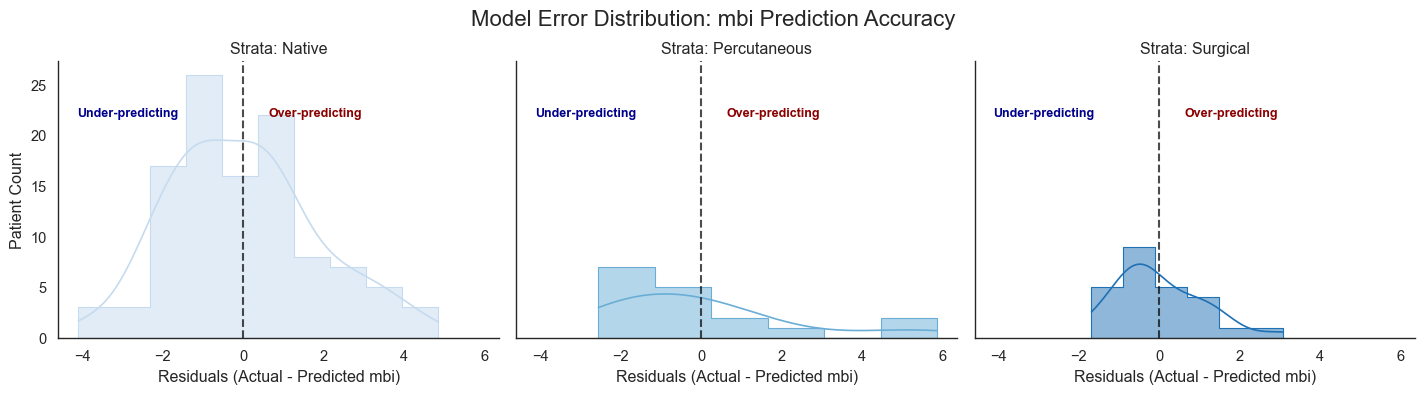

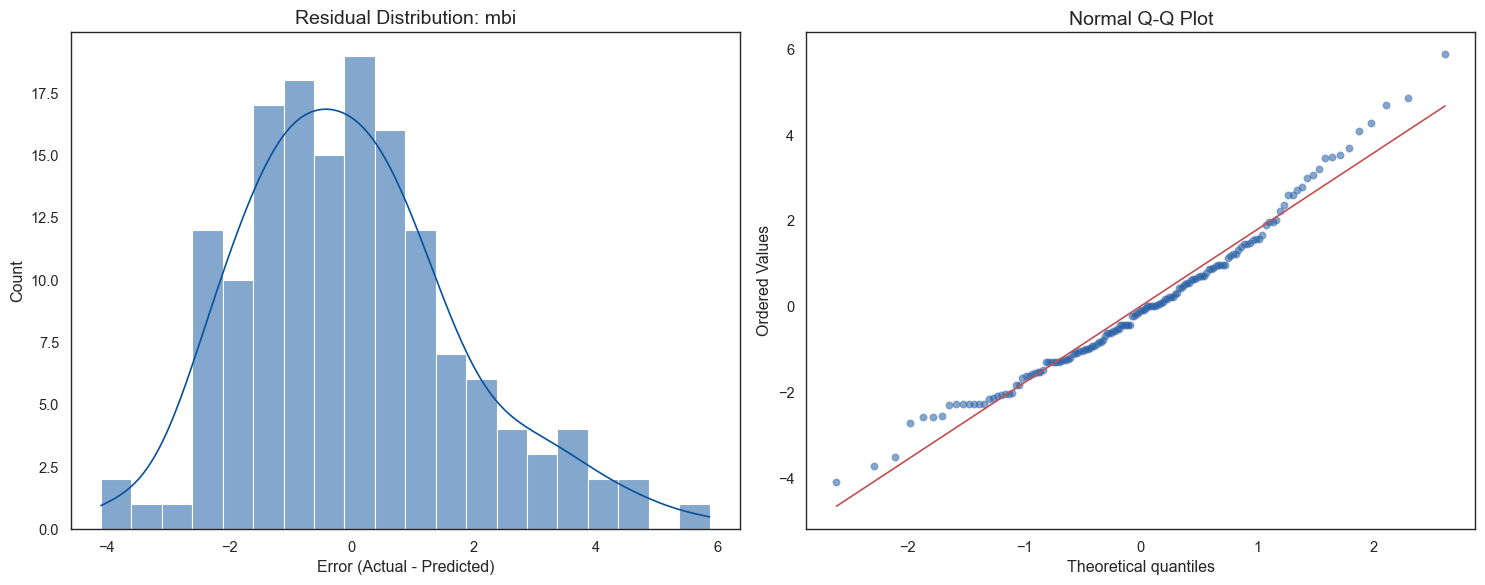

In [46]:
# Variables to be used for regression
"""
These lists are left empty because we want to run an exploratory regression first
This will give us an overview into the differences per intervention status
So far, we are going to focus on lesions only, to see how much of this data's MBI
is explained by anatomy of the lesions.
"""
# This are the lists to be passed to the method run_regression
# We are starting with the anatomic variables and then add/modify accordingly
config.regression_echo = []
config.regression_demographics = []
config.regression_lesions = ['sev_ms','sev_mr', 'sev_as', 'sev_ar', 'mixed_mitral', 'mixed_aortic', 'multi_valve', 'sev_ph', 'afib_present']

# Runs regression across all intervention groups
mbi_mismatch = stats.run_regression(y_var='mbi')

# To use residual_distribution method, make sure no strata is selected
print("Residuals visualization to compare prediciton errors across intervention groups\n" + '-'*40)
viz.residual_distribution(mbi_mismatch, y_var='mbi')
viz.diagnostic_plots(mbi_mismatch, y_var='mbi')
# viz.residual_vs_fitted(mbi_mismatch, y_var='MBI')

In [47]:
# Runs regressions using MBI as a dependent variable, only on the Native cohort
config.regression_lesions = ['sev_ms','sev_mr', 'sev_as', 'sev_ar', 'mixed_mitral', 'mixed_aortic', 'multi_valve', 'sev_ph', 'afib_present']
mbi_mismatch_native = stats.run_regression(y_var='mbi', strata='Native')


DEEP DIVE: mbi NATIVE (n=110)
                            OLS Regression Results                            
Dep. Variable:                    mbi   R-squared:                       0.282
Model:                            OLS   Adj. R-squared:                  0.217
Method:                 Least Squares   F-statistic:                     4.363
Date:                Wed, 03 Jun 2026   Prob (F-statistic):           8.10e-05
Time:                        11:09:04   Log-Likelihood:                -222.53
No. Observations:                 110   AIC:                             465.1
Df Residuals:                     100   BIC:                             492.1
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            

<div style="padding: 15px; border: 1px solid #003152; border-radius: 5px; background-color: #eff9ff; color: #003152;">
    <strong style="font-size: 1.2em;">Clinical Synthesis: Determinants of Medication Burden</strong> 
    <p><b>1. Primary Drivers:</b> In the <b>Native</b> cohort, <i>Atrial Fibrillation</i> (coef. 1.87), <i>Pulmonary Hypertension</i> (coef. 0.60), and <i>Mitral Regurgitation</i> (coef. 0.56) are the statistically significant predictors of MBI. This confirms that medication strategies in non-operative patients are primarily "defensive," targeting symptomatic complications like congestion and rhythm instability.</p>
    <p><b>2. The "Mixed Mitral" Signal:</b> Although <i>Mixed Mitral Disease</i> did not reach statistical significance (<i>p > 0.05</i>), its high coefficient of <b>1.37</b> suggests a potent clinical impact. This likely represents an additive or exponential burden where the combination of stenosis and regurgitation warrants a thorough review and confirmatory transesophageal ecocardiographic evaluation than isolated lesions.</p>
    <p><b>3. Stratified Baseline (The Constant):</b> The model reveals a descending baseline burden as we move toward definitive intervention. The <b>Native</b> constant (2.29) reflects high background therapy for "pre-op" stabilization, whereas the <b>Surgical</b> constant is significantly lower (0.43), signaling a reduced reliance on chronic heart failure medications following anatomical correction.</p>
    <p><b>4. Model Performance:</b> The <i>R squared</i> of <b>0.28</b> indicates that while valvular lesions are key drivers, roughly 72% of the variance in medication burden is influenced by other factors. We will now run subsequent regression to see if by adding specific variables we improve the model's performance.</p>
    <p><b>5. Residual Analysis (The Triage Gap):</b> The histograms reveal the 'clinical outliers' that the model cannot explain. The <b>low-end tail in the Native group</b> likely represents medical undertreatment (anatomically sick patients on minimal medication). Conversely, the <b>high-end "chimneys" in Native and Percutaneous strata</b> highlight the 'Mismatch' group—patients whose high medication burden is disproportionate to their echo findings, suggesting uncaptured frailty or non-valvular complications.</p>
</div>

In [48]:
# Now we add echo parameters
config.regression_echo = ['rvsp_imputed', 'lvidd_imputed', 'ao_v2_max_imputed', 'ms_mg_mmhg_imputed', 'la_size_score', 'lvef_score']
config.regression_lesions = ['sev_ms','sev_mr', 'sev_as', 'sev_ar', 'mixed_mitral', 'mixed_aortic', 'multi_valve', 'afib_present']
mbi_mismatch_native = stats.run_regression(y_var='mbi', strata='Native')


DEEP DIVE: mbi NATIVE (n=110)
                            OLS Regression Results                            
Dep. Variable:                    mbi   R-squared:                       0.348
Model:                            OLS   Adj. R-squared:                  0.252
Method:                 Least Squares   F-statistic:                     3.623
Date:                Wed, 03 Jun 2026   Prob (F-statistic):           8.30e-05
Time:                        11:09:04   Log-Likelihood:                -217.22
No. Observations:                 110   AIC:                             464.4
Df Residuals:                      95   BIC:                             504.9
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const

<div style="padding: 15px; border: 1px solid #003152; border-radius: 5px; background-color: #eff9ff; color: #003152;">
    <strong style="font-size: 1.2em;">Deep Dive: Native Cohort Refined Model</strong> 
    <p><b>1. Hemodynamic Dominance:</b> By transitioning from categorical scores to continuous echo data, <i>RVSP</i> emerges as a primary driver of medication burden (<i>p < 0.001</i>). This confirms that in the Native cohort, the MBI functions as a reliable pharmacological proxy for pulmonary congestion and right-heart pressure.</p>
    <p><b>2. Improved Explanatory Power:</b> Even after removing categorical lesion scores to reduce collinearity, the <i>R-squared</i> stands at <b>0.34</b>. This validates that medication burden is heavily influenced by "how the heart is compensating" (pressures and chamber sizes) rather than just the presence of a sick valve.</p>
    <p><b>3. The "Mixed Mitral" Multiplier:</b> The coefficient for <i>Mixed Mitral</i> disease has increased to <b>1.69</b> but still did not reach statistical significance (<i>p > 0.05</i>). This is a key finding: having both stenosis and regurgitation could potentially add almost 2 full units to the MBI, representing a potential clinical predictor in the model, identifying a highly complex phenotype that warrants priority TEE (transesophageal echocardiographic) evaluation.</p>
</div>

In [49]:
# Now we add demograhic variables
config.regression_echo = ['rvsp_imputed', 'lvidd_imputed', 'ao_v2_max_imputed', 'ms_mg_mmhg_imputed', 'la_size_score', 'lvef_score']
config.regression_demographics = ['age', 'weight', 'Gender_Male']
config.regression_lesions = ['sev_ms','sev_mr', 'sev_as', 'sev_ar', 'mixed_mitral', 'mixed_aortic', 'multi_valve', 'afib_present']
mbi_mismatch_native = stats.run_regression(y_var='mbi', strata='Native')


DEEP DIVE: mbi NATIVE (n=110)
                            OLS Regression Results                            
Dep. Variable:                    mbi   R-squared:                       0.433
Model:                            OLS   Adj. R-squared:                  0.335
Method:                 Least Squares   F-statistic:                     4.433
Date:                Wed, 03 Jun 2026   Prob (F-statistic):           2.06e-06
Time:                        11:09:04   Log-Likelihood:                -209.58
No. Observations:                 110   AIC:                             453.2
Df Residuals:                      93   BIC:                             499.1
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const

<div style="padding: 15px; border: 1px solid #003152; border-radius: 5px; background-color: #eff9ff; color: #003152;"> <strong style="font-size: 1.2em;">Final Synthesis: The Integrated Native Model</strong>
<p><b>1. The "Mixed Mitral" Multiplier:</b> The coefficient for <i>Mixed Mitral</i> disease has increased to <b>1.97</b> while still not being statistical significant (<i>p < 0.054</i>).</p>
<p><b>1. The Weight Factor:</b> Patient <i>Weight</i> emerges as a highly significant driver (<b>coef. 0.035, p = 0.011</b>). This indicates that for every 10kg increase in body weight, medication burden increases significantly, likely due to dosing requirements or weight-related comorbid stability issues.</p>
<p><b>2. Hemodynamic Stability:</b> <i>RVSP</i> remains the most consistent and reliable predictor (<b>p < 0.001</b>). The model consistently identifies pulmonary pressure as the primary "trigger" that clinicians respond to when escalating pharmacological therapy.</p>
<p><b>3. Model Maturity:</b> Achieving an <b>R-squared of 0.43</b> with a stable <b>Durbin-Watson (1.97)</b> suggests that the model is well-specified and free of major autocorrelation issues. This integrated approach successfully bridges the gap between raw echo data and clinical practice.</p>
</div>


CROSS-STRATA COMPARISON: rvsp_imputed


,Native Coef,Percutaneous Coef,Surgical Coef
const,51.253 *,-9.875,-
age,-0.057,0.099,0.040
weight,-0.262,0.444,-0.010
mbi,4.575 **,-1.531,0.047
sev_ms,-1.959,3.039,1.296
sev_mr,-1.427,-9.637,2.146
sev_as,-4.021,-0.000,0.259
sev_ar,-0.075,0.000,1.238
mixed_mitral,-4.127,-3.212,-0.000
mixed_aortic,11.564,0.000,-0.000


Notes:   ** - p < 0.01 | * - p<0.05

Residuals visualization to compare prediciton errors across intervention groups
----------------------------------------


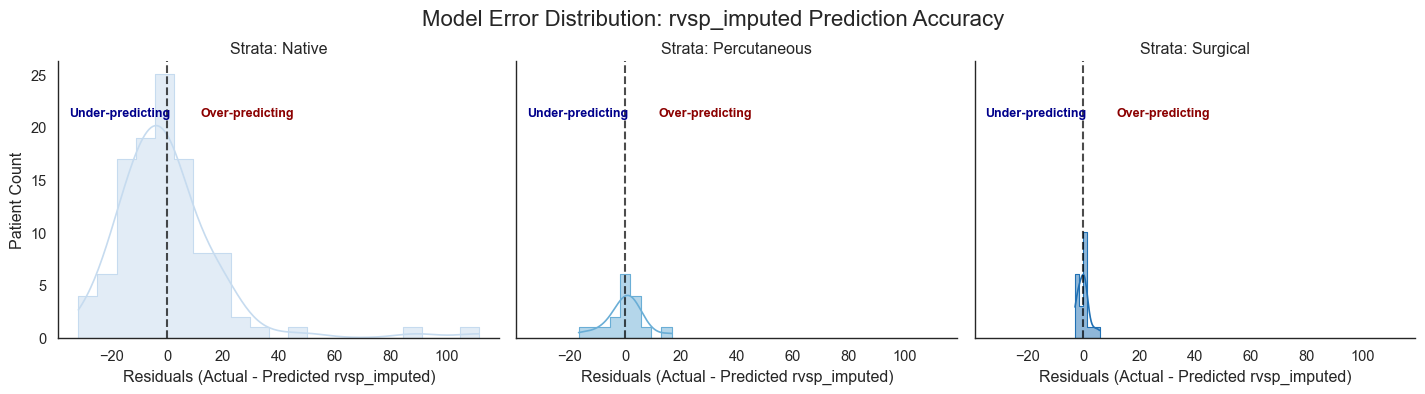

In [50]:
# Runs regressions using RVSP as a dependent variable
# We will add MBI to the demographics group
config.regression_echo = ['lvidd_imputed', 'ao_v2_max_imputed', 'ms_mg_mmhg_imputed', 'la_size_score', 'lvef_score']
config.regression_demographics = ['age', 'weight', 'Gender_Male', 'mbi']
config.regression_lesions = ['sev_ms','sev_mr', 'sev_as', 'sev_ar', 'mixed_mitral', 'mixed_aortic', 'multi_valve', 'afib_present']
rvsp_mismatch = stats.run_regression(y_var='rvsp_imputed')

print("Residuals visualization to compare prediciton errors across intervention groups\n" + '-'*40)
viz.residual_distribution(rvsp_mismatch, y_var='rvsp_imputed')

In [51]:
# We will limit the regression's strata to Native only
config.regression_echo = ['lvidd_imputed', 'ao_v2_max_imputed', 'ms_mg_mmhg_imputed', 'la_size_score', 'lvef_score']
config.regression_demographics = ['age', 'weight', 'Gender_Male', 'mbi']
config.regression_lesions = ['sev_ms','sev_mr', 'sev_as', 'sev_ar', 'mixed_mitral', 'mixed_aortic', 'multi_valve', 'afib_present']
rvsp_mismatch_native = stats.run_regression(y_var='rvsp_imputed', strata='Native')


DEEP DIVE: rvsp_imputed NATIVE (n=110)
                            OLS Regression Results                            
Dep. Variable:           rvsp_imputed   R-squared:                       0.259
Model:                            OLS   Adj. R-squared:                  0.131
Method:                 Least Squares   F-statistic:                     2.031
Date:                Wed, 03 Jun 2026   Prob (F-statistic):             0.0186
Time:                        11:09:05   Log-Likelihood:                -482.18
No. Observations:                 110   AIC:                             998.4
Df Residuals:                      93   BIC:                             1044.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

<div style="padding: 15px; border: 1px solid #003152; border-radius: 5px; background-color: #eff9ff; color: #003152;">
    <strong style="font-size: 1.2em;">Hemodynamic Analysis: Drivers of Pulmonary Pressure</strong> 
    <p><b>1. MBI as a Hemodynamic Biomarker:</b> In the Native cohort, the <i>Medication Burden Index</i> is the most powerful predictor of actual pulmonary pressure (<b>coef. 4.57, p < 0.001</b>). This confirms that for every 1-unit increase in MBI, RVSP increases by approximately 4.5 mmHg, validating the index as a robust "digital biomarker" for hemodynamic severity in resource-limited settings.</p>
    <p><b>2. Mechanical Drivers of PH:</b> <i>Mitral Mean Gradient (MS MG)</i> could be a primary mechanical driver of right-heart strain (<b>coef. 1.00, p = 0.085</b>). This trend identifies stenotic obstruction as a key physiological target for alleviating pulmonary hypertension, even when controlling for rhythm and baseline medication.</p>
    <p><b>3. Residual Analysis (The "Chimney" Effect):</b> The RVSP histogram reveals massive 'Over-prediction' outliers in the <b>Native</b> group, with residuals reaching <b>+110 mmHg</b>. These patients represent the <b>"Critical Mismatch"</b>—individuals whose lung pressures have decoupled from their valve anatomy.</p>
    <p><b>4. Stratified Predictability:</b> The distribution of errors is significantly "tighter" in <b>Surgical</b> and <b>Percutaneous</b> strata compared to the Native group. This indicates that post-intervention hemodynamics follow a more standardized physiological path, whereas <b>Native</b> disease is characterized by high-variance "Natural History" outliers that the model identifies but cannot fully normalize.</p>
    <p><b>5. Triage Utility:</b> The combination of a high <i>Kurtosis (15.03)</i> and the <b>Native low-end tail</b> (under-predicted severity) highlights a critical "Treatment Gap." Patients in these tails are either physiologically compensated survivors or medically undertreated.</p>
</div>


CROSS-STRATA COMPARISON: lvef_score


,Native Coef,Percutaneous Coef,Surgical Coef
const,86.247 **,73.369 **,62.000 **
age,0.058,0.087,0.000
weight,-0.093,-0.072,0.000
mbi,-0.677,-0.540,-0.000
sev_ms,0.558,0.404,0.000
sev_mr,-0.846,-3.881 *,0.000
sev_as,-0.455,-0.000 **,0.000
sev_ar,-3.694,-0.000 **,-0.000
mixed_mitral,9.763,-1.294 *,-0.000 **
mixed_aortic,17.748,-0.000 **,-0.000 **


Notes:   ** - p < 0.01 | * - p<0.05

Residuals visualization to compare prediciton errors across intervention groups
----------------------------------------


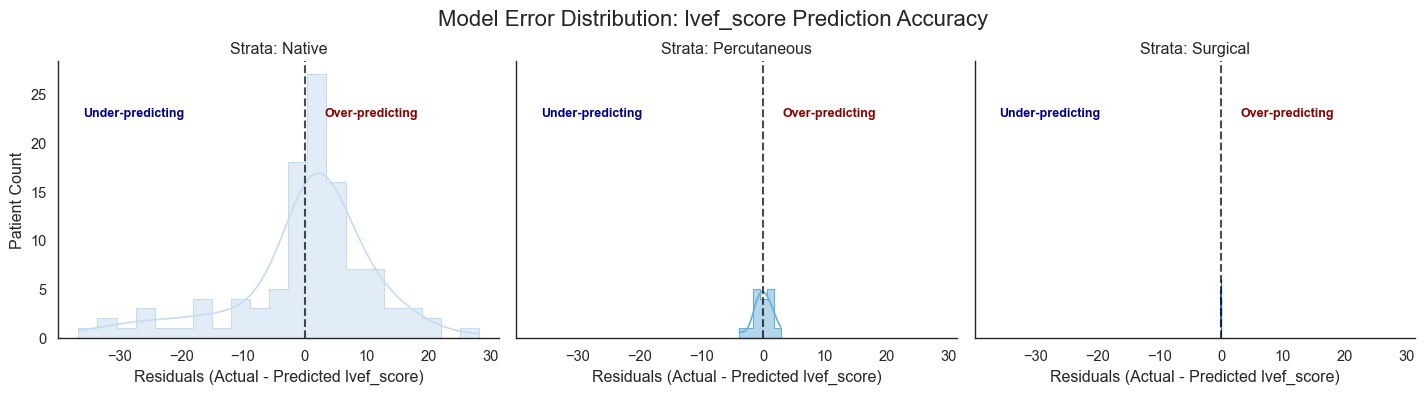

In [52]:
# Runs regressions using LVEF as a dependent variable
config.regression_echo = ['rvsp_imputed', 'lvidd_imputed', 'ao_v2_max_imputed', 'ms_mg_mmhg_imputed', 'la_size_score', 'lvef_score']
config.regression_demographics = ['age', 'weight', 'Gender_Male', 'mbi']
config.regression_lesions = ['sev_ms','sev_mr', 'sev_as', 'sev_ar', 'mixed_mitral', 'mixed_aortic', 'multi_valve', 'afib_present']
lvef_mismatch = stats.run_regression(y_var='lvef_score')

print("Residuals visualization to compare prediciton errors across intervention groups\n" + '-'*40)
viz.residual_distribution(lvef_mismatch, y_var='lvef_score')

In [53]:
# We will limit the regression's strata to Native only
config.regression_echo = ['rvsp_imputed', 'lvidd_imputed', 'ao_v2_max_imputed', 'ms_mg_mmhg_imputed', 'la_size_score', 'lvef_score']
config.regression_demographics = ['age', 'weight', 'Gender_Male', 'mbi']
config.regression_lesions = ['sev_ms','sev_mr', 'sev_as', 'sev_ar', 'mixed_mitral', 'mixed_aortic', 'multi_valve', 'afib_present']
lvef_mismatch_native = stats.run_regression(y_var='lvef_score', strata='Native')


DEEP DIVE: lvef_score NATIVE (n=110)
                            OLS Regression Results                            
Dep. Variable:             lvef_score   R-squared:                       0.264
Model:                            OLS   Adj. R-squared:                  0.138
Method:                 Least Squares   F-statistic:                     2.090
Date:                Wed, 03 Jun 2026   Prob (F-statistic):             0.0150
Time:                        11:09:05   Log-Likelihood:                -421.96
No. Observations:                 110   AIC:                             877.9
Df Residuals:                      93   BIC:                             923.8
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------

<div style="padding: 15px; border: 1px solid #003152; border-radius: 5px; background-color: #eff9ff; color: #003152;"> <strong style="font-size: 1.2em;">Mechanical Analysis: Drivers of Systolic Function (LVEF)</strong>
    <p><b>1. The Native Baseline (The Compensation Phase):</b> The <b>Native</b> constant (<b>86.2</b>) is significantly higher than the intervention strata (~60). This suggests that many patients in the Native cohort are in a <i>hyperdynamic state</i>, where the heart over-contracts to compensate for severe regurgitation or stenosis. This is a fragile equilibrium, not a sign of health.</p>
    <p><b>2. Dilation vs. Performance:</b> <i>LVIDd</i> is the strongest negative predictor of function (<b>coef. -4.66, p < 0.01</b>). As the ventricle dilates, it loses the ability to maintain this hyperdynamic compensation, signaling a transition from "compensated" to "decompensated" heart failure.</p>
    <p><b>3. The Residual "Chimney" (Hyperdynamic Outliers):</b> The Native histogram shows a narrow peak at <b>+25</b>. These are the most hyperdynamic patients in the cohort—those whose Ejection Fractions are extremely high despite significant disease. In a surgical triage context, these patients often require urgent intervention before the ventricle "burns out" and function drops.</p>
    <p><b>4. Post-Intervention Normalization:</b> The lower constants (60%) and tighter residuals in the <b>Surgical</b> and <b>Percutaneous</b> groups represent the achievement of a physiological "new normal." Once the mechanical lesion is fixed, the hyperdynamic stress is relieved, and the heart stabilizes at a lower, more sustainable contractile level.</p>
    <p><b>5. AFib & Remodeling:</b> The trending negative impact of <i>AFib</i> (<b>coef. -12.16, p < 0.05</b>) suggests that rhythm instability is one of the primary factors that "breaks" the hyperdynamic compensation, leading to a rapid decline in LVEF.</p>
</div>

ROC visualization for mbi
----------------------------------------


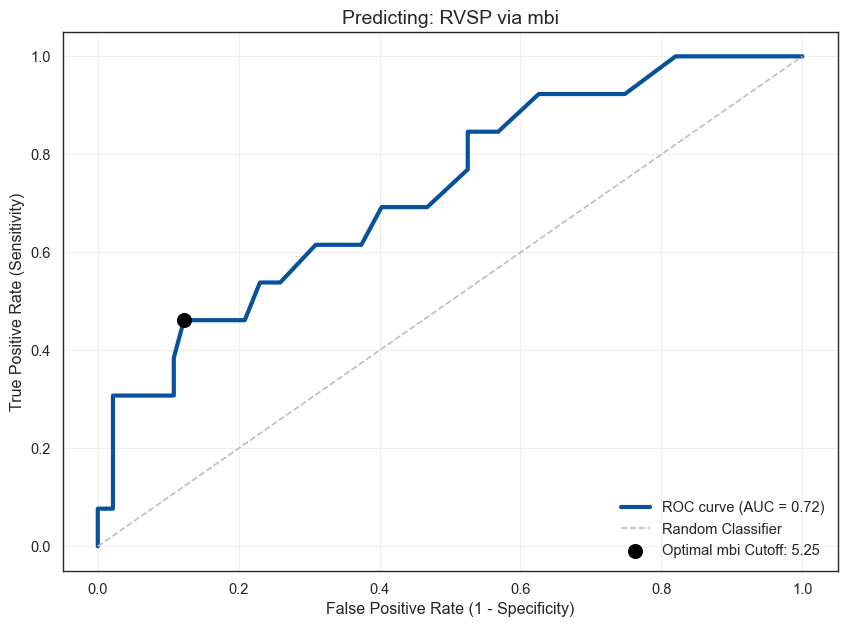

Analysis Complete: A value of mbi above 5.25 is the best predictor for this variable.

MBI Threshold Validation (> 5.25)
----------------------------------------
F1-Score:  0.288
Precision: 0.850 (Reliability: When MBI is high, is the patient actually sick?)
Recall:    0.173 (Sensitivity: Does MBI catch all the sick patients?)

Confusion matrix visualization
----------------------------------------


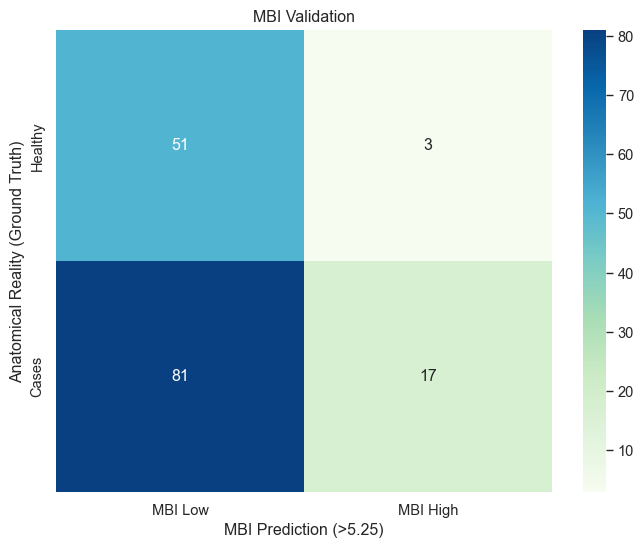

In [54]:
# ROC curve to predict high RVSP via MBI
high_rvsp = df['rvsp_imputed'] > 60
stats.roc(predictor_col='mbi', target=high_rvsp, label="RVSP")

# Apply the MBI Cutoff (The Predictor)
mbi_cutoff = 5.25
df['MBI_Predicted_High'] = (df['mbi'] > mbi_cutoff).astype(int)
matrix_rvsp = stats.validate_predictor(mbi_cutoff)
viz.validate_vis(matrix_rvsp, 
                 'MBI Prediction (>5.25)', 'Anatomical Reality (Ground Truth)', 
                 'MBI Validation'
)

<div style="padding: 15px; border: 1px solid #003152; border-radius: 5px; background-color: #eff9ff; color: #003152;">
    <strong style="font-size: 1.2em;">Surrogate Marker Validation: MBI as a Proxy for Hemodynamic Collapse</strong> 
    <p>This validation cycle evaluates how cleanly the Medication Burden Index (MBI) serves as a digital proxy for severe pulmonary hypertension (defined clinically as an imputed Right Ventricular Systolic Pressure, <strong>RVSP > 60 mmHg</strong>).</p>
    <p><strong>Predictive Threshold Signal:</strong> Youden’s J-statistic isolates an <strong>MBI cutoff of 5.25</strong> as the maximum predictive threshold for advanced hemodynamic stress.</p>
    <p><strong>High Precision (PPV = 85.0%):</strong> When a patient crosses the 5.25 MBI threshold, the index flags severe RVSP elevation with <strong>85% positive predictive accuracy</strong>. In resource-constrained global health missions, this high-precision signal serves as a rule-in mechanism for prioritized transesophageal echocardiographic scheduling</p>
    <p><strong>The Asymmetric Sensitivity (Recall = 17.3%):</strong> The low sensitivity confirms that while an intense medication regimen heavily maps to a sick right ventricle, advanced pulmonary vascular disease frequently remains completely un-medicated in real-world clinical cohorts. This represents a clear therapeutic diagnostic gap.</p>
</div>

### 📊 Strategic Cohort Stratification & Baseline Characteristics
---

To translate the dataset findings into actionable operational strata, the cohort is classified into three distinct **Medication Burden Index (MBI) Triage Zones**. These boundaries are determined by balancing pharmacological baseline profiles against known intervention windows:

* **Zone 1: The Stable/Monitor Tier (MBI < 4.0):** This represents patients near or below the cohort's native baseline constant ($2.29$). These individuals exhibit managed or early-stage disease where advanced interventions can be safely deferred in favor of longitudinal monitoring.
* **Zone 2: The Optimal Intervention Window (MBI 4.0 – 5.5):** This zone captures patients experiencing significant anatomical and hemodynamic progression who have not yet crossed into pharmacological exhaustion. This is the highest-yield tier for surgical or percutaneous candidate selection.
* **Zone 3: The High-Risk / Palliative Tier (MBI > 5.5):** This represents the pharmacological ceiling. Patients in this stratum demonstrate advanced heart failure or severe secondary complications (e.g., severe Pulmonary Hypertension), indicating a high probability of surgical futility or a requirement for intensive pre-operative optimization.

In [55]:
# MBI zone cutoffs and labels
bins = [0, 4.0, 5.5, np.inf]
labels = ['Zone 1', 'Zone 2', 'Zone 3']

print("Table 1: Baseline Characteristics Stratified by MBI Triage Zone")
table_1 = tabs.table_one()
display(table_1)

print("Table 2: Baseline Characteristics stratified by valve status")
table_2 = tabs.table_two()
display(table_2)

Table 1: Baseline Characteristics Stratified by MBI Triage Zone


,All Patients (N=152),Zone 1 (n=113),Zone 2 (n=22),Zone 3 (n=17)
Age (years),47.1 ± 15.7,45.3 ± 16.4,54.6 ± 10.1,49.8 ± 13.4
Female (%),64.5%,58.4%,77.3%,88.2%
Heart Rate (bpm),76.6 ± 14.1,76.2 ± 14.2,79.5 ± 14.2,75.8 ± 14.1
Systolic BP (mmHg),124.6 ± 18.7,127.4 ± 18.7,113.6 ± 17.0,120.9 ± 15.2
Diastolic BP (mmHg),76.7 ± 12.5,77.7 ± 12.9,72.9 ± 10.3,75.2 ± 11.6
RVSP (mmHg),33.3 ± 20.3,30.7 ± 17.2,35.5 ± 16.2,48.0 ± 34.3
LVEF (%),58.2 ± 11.4,59.3 ± 10.5,54.4 ± 14.5,56.1 ± 12.1
MBI,2.9 ± 2.1,1.9 ± 1.2,4.7 ± 0.5,7.2 ± 1.3


Table 2: Baseline Characteristics stratified by valve status


,All Patients (N=152),Native (n=110),Percutaneous (n=17),Surgical (n=25)
Age (years),47.1 ± 15.7,47.7 ± 16.0,42.9 ± 14.4,47.4 ± 14.9
Female (%),64.5%,61.8%,88.2%,60.0%
Heart Rate (bpm),76.6 ± 14.1,76.3 ± 14.5,71.2 ± 13.2,81.5 ± 11.8
Systolic BP (mmHg),124.6 ± 18.7,124.8 ± 19.4,123.8 ± 18.2,124.7 ± 16.3
Diastolic BP (mmHg),76.7 ± 12.5,76.6 ± 13.6,75.7 ± 9.7,77.7 ± 8.2
RVSP (mmHg),33.3 ± 20.3,35.8 ± 22.6,30.3 ± 13.7,24.3 ± 3.7
LVEF (%),58.2 ± 11.4,57.1 ± 13.1,60.2 ± 3.9,62.0 ± 0.0
MBI,2.9 ± 2.1,3.0 ± 2.2,3.2 ± 2.6,1.9 ± 1.4


### 📉 Visualizing Diagnostic Discordance & Clinical Phenotypes
---

Mapping the interaction between physiological stress and therapeutic suppression reveals a complex clinical reality. To expose these hidden phenotypes, the cohort's diagnostic profile is evaluated across two distinct analytical lenses:

**MBI vs. RVSP Analysis:** This plot maps individual patient positions by crossing the Medication Burden Index (Index Test) against Right Ventricular Systolic Pressure (Reference Standard). The shaded regression interval represents the expected trend of Concordant disease progression. Crucially, this visualization highlights two highly problematic diagnostic deviations:

* **The Complexity Zone (Blue):** Patients demonstrating artificially suppressed or "moderate" hemodynamics achieved only via exceptional, high-intensity pharmacological management.

* **The Critical Zone (Red):** Under-medicated individuals exhibiting advanced hemodynamic failure relative to their therapeutic coverage.

**Clinical Drivers of Discordance:** To move past abstract data distribution, this frequency breakdown isolates the specific pathophysiological etiologies (e.g., mixed mitral disease, atrial fibrillation, significant pulmonary hypertension) that actively fuel these discordant states, pinning down the underlying clinical triggers forcing patients out of equilibrium.

By evaluating where patients fall relative to the expected concordant baseline, we can deconstruct the true operational and physiological toll required to maintain superficial stability.

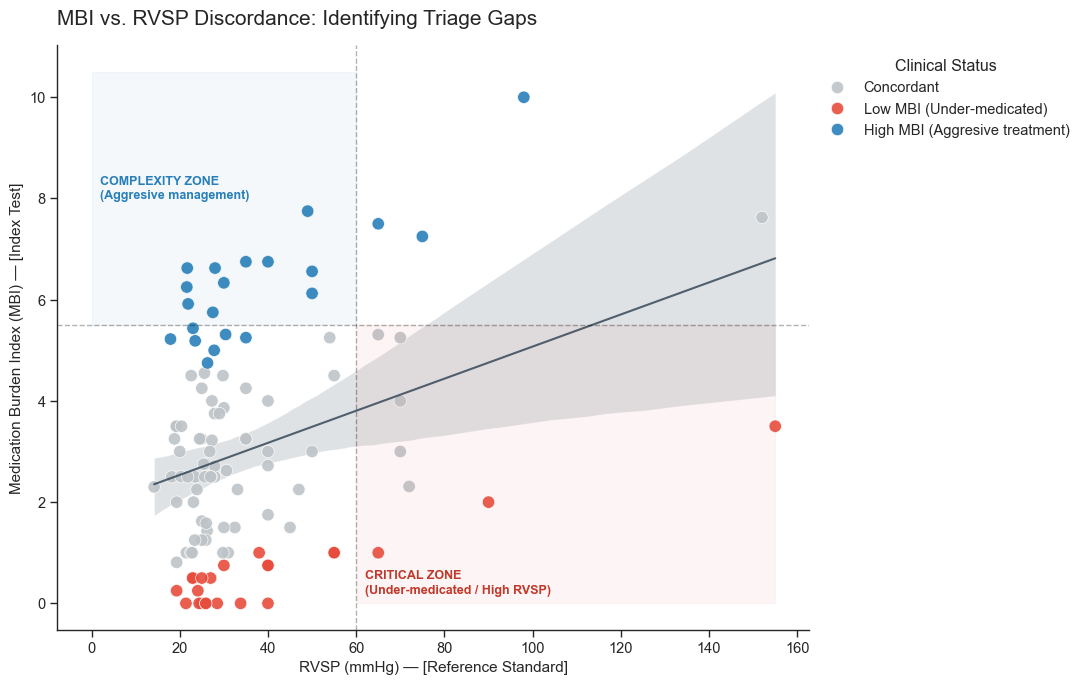

Clinical Drivers of Discordance (Frequency Counts)
----------------------------------------
Under-medicated (n=23)
Aggresive treatment (n=21)


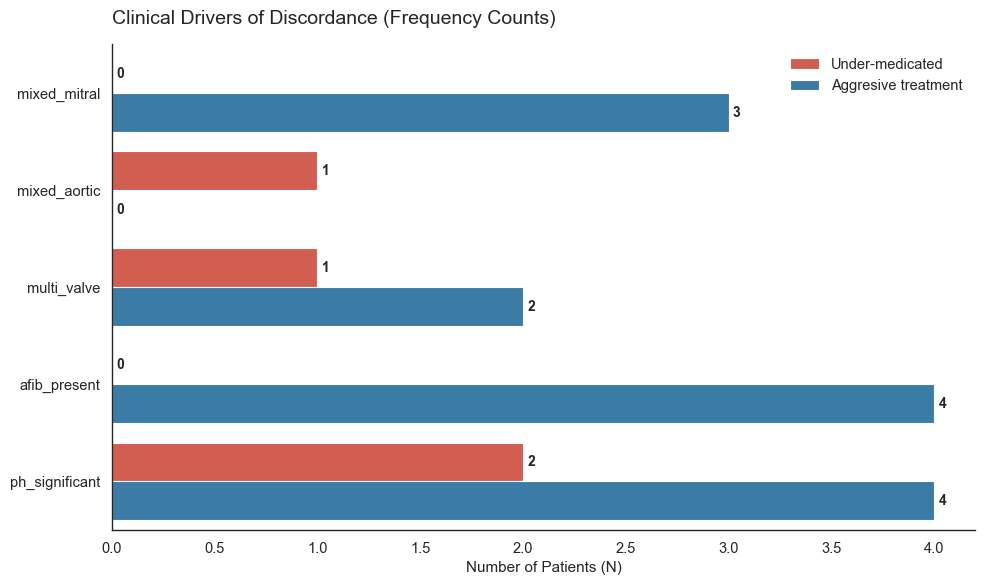

In [56]:
# 1. Run scatter plot and capture the calculated native dataframe cleanly
native_data = viz.plot_discordance_scatter()

# 2. Run the horizontal bar chart passing the generated tracking frame
viz.plot_discordance_bars(native_data)

<div style="padding: 15px; border: 1px solid #003152; border-radius: 5px; background-color: #eff9ff; color: #003152;">
<strong style="font-size: 1.2em;">Deep Dive: The Pharmacological Cost of Hemodynamic Stability</strong>

<p><b>1. The "Masked" Discordance (The Complexity Zone):</b> Table 1 identifies the <b>Aggressive Treatment (n=17)</b> group as the most clinically deceptive. Despite having an <b>RVSP (48.0 mmHg)</b> that appears "moderate" on an Echo, they require an <b>MBI of 7.2</b> (the highest in the study) to maintain that pressure.</p>

<p><b>2. Threshold Validation (The 5.25 Red Flag):</b> Table 2 validates <b>Zone 3 (MBI > 5.25)</b> as the true "Danger Zone." This cohort captures the highest mean <b>RVSP (48.0 ± 34.3 mmHg)</b> and the highest percentage of females (88.2%). This suggests that as the MBI crosses the 5.25 mark, the "masking" effect of medication is overwhelmed by the underlying disease, making this the optimal cutoff for intervention triage.</p>

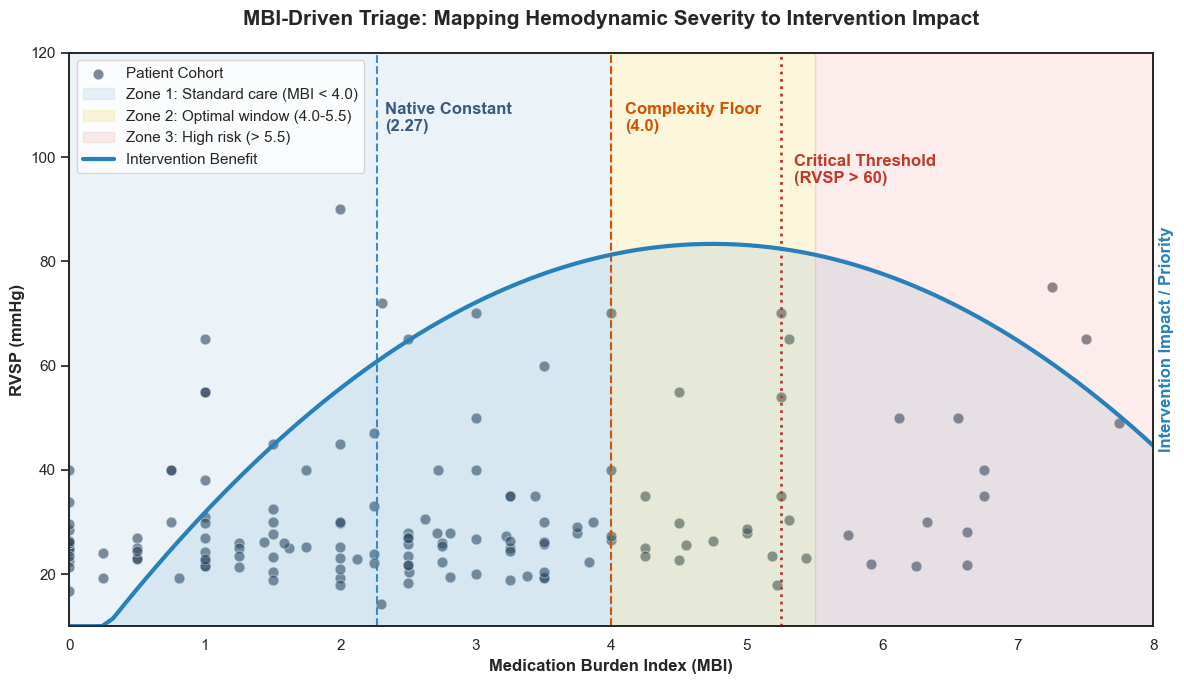

In [57]:
# 3. Generate the overarching triage map
viz.plot_triage_map()

<div style="padding: 15px; border: 1px solid #003152; border-radius: 5px; background-color: #eff9ff; color: #003152;"> <strong style="font-size: 1.2em;">MBI-Driven Triage: From Baseline to Intervention</strong>
<p><b>1. The "Native Constant" (MBI 2.27):</b> Our statistical model identifies <b>2.27</b> as the cohort's baseline medication burden. A patient at this level represents the "standard" valvular case. Any value above this indicates a physiological demand exceeding the population average.</p>
<p><b>2. The Complexity Floor (MBI 4.0):</b> By setting the intervention bar at <b>4.0</b>, we move significantly beyond the 2.27 baseline into the <b>Top 25%</b> of cohort severity. This represents the point where baseline physiological constants are no longer sufficient, and the body requires significant pharmacological support.</p>
<p><b>3. Capturing the "Mixed" Signal:</b> The <b>Mixed Mitral</b> coefficient (2.22) is roughly equal to our <b>Native Constant</b> (2.27). In practice, an MBI of ~4.5 is the exact mathematical point where a baseline patient starts exhibiting the additive burden of a mixed-lesion phenotype. This validates our <b>4.0 Complexity Floor</b> as the entry point for high-priority cases.</p>
<p><b>4. The Critical Threshold (MBI 5.25):</b> At an MBI of <b>5.25</b> (more than double the baseline), we find the optimal predictor for <b>Critical Pulmonary Hypertension (RVSP > 60 mmHg)</b>. With a <b>Precision of 85%</b>, patients exceeding this score are highly likely to be in a state of advanced hemodynamic decompensation.</p>
<p><b>5. The "Intervention Window" (MBI 4.0 – 5.5):</b>
    <ul>
        <li><b>Zone 1: The "Stable/Monitor" Tier (MBI < 4.0):</b> Standard care. Patients near the <b>2.27 baseline</b> are likely stable and can be managed medically or deferred.</li>
        <li><b>Zone 2: The "Optimal window" (MBI 4.0 – 5.5):</b> This is the high-yield window. These patients have significant disease (MBI > 4.0) and include the critical PH cohort (MBI 5.25), but have not yet reached the level of pharmacological exhaustion.</li>
        <li><b>Zone 3: The "High-Risk / Palliative" Tier (MBI > 5.5):</b> The <b>High-Risk Ceiling</b>. Medication burden at this level suggests end-stage failure, requiring senior-level review for surgical futility.</li>
    </ul>
</p>
<p><b>6. Operational Impact:</b> This framework allows the intake team to "color-code" the patient queue, right at the registration desk.</p>
</div>